# BANC Neurons Dataset — Visualization

Exploratory visualization of `neurons.csv.gz` (115,151 neurons).

**Columns:** `Root ID`, `Top in/out region`, `Community labels`, `Predicted NT type`, `Predicted NT confidence`, `Verified NT type`, `Verified Neuropeptide`, `Body Part`

**Topics covered:**
1. Data overview & missing values
2. Top in/out region distribution (top-30)
3. Predicted NT type distribution
4. Predicted NT confidence distribution
5. Body part distribution
6. Community labels (top-20)
7. NT type × Body part heatmap
8. Top-15 regions × NT type heatmap
9. Verified vs Predicted NT type comparison
10. Summary statistics table

In [1]:
# ── Imports & data loading ───────────────────────────────────────────────────
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')   # make banc_utils importable from this directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from banc_utils import (
    load_neurons,
    neuron_region_counts,
    neuron_nt_type_counts,
    neuron_body_part_counts,
    neuron_community_label_counts,
    neuron_nt_confidence_stats,
    missing_data_summary,
    plot_bar, plot_barh, plot_histogram, plot_pie, plot_heatmap,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

neurons_df = load_neurons('neurons.csv.gz')
print(f'Loaded neurons: {neurons_df.shape[0]:,} rows x {neurons_df.shape[1]} columns')
neurons_df.head(3)

Loaded neurons: 115,151 rows x 21 columns


,Root ID,Top in/out region,Community labels,Predicted NT type,Predicted NT confidence,Verified NT type,Verified Neuropeptide,Body Part,Function,Flow,...,Class,Sub Class,Hemilineage,Nerve,Soma side,Primary Cell Type,Alternative Cell Type(s),Cable length (nm),Surface area (nm^2),Volume (nm^3)
0,720575940381905254,NO_CONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,720575940386709331,NO_CONS,soma in brain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,720575940387110289,NO_CONS,sensory neuron,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data Overview & Missing Values

Shape: (115151, 21)

Dtypes:
Root ID                       int64
Top in/out region            object
Community labels             object
Predicted NT type            object
Predicted NT confidence     float64
Verified NT type             object
Verified Neuropeptide        object
Body Part                    object
Function                     object
Flow                         object
Super Class                  object
Class                        object
Sub Class                    object
Hemilineage                  object
Nerve                        object
Soma side                    object
Primary Cell Type            object
Alternative Cell Type(s)     object
Cable length (nm)           float64
Surface area (nm^2)         float64
Volume (nm^3)               float64
dtype: object

Basic stats:


,Root ID,Top in/out region,Community labels,Predicted NT type,Predicted NT confidence,Verified NT type,Verified Neuropeptide,Body Part,Function,Flow,...,Class,Sub Class,Hemilineage,Nerve,Soma side,Primary Cell Type,Alternative Cell Type(s),Cable length (nm),Surface area (nm^2),Volume (nm^3)
count,1.151510e+05,115151,100255,109485,109485.000000,40568,4833,13441,13852,87837,...,61409,33035,43241,13860,114858,87642,87642,0.0,0.0,0.0
unique,NaN,1092,2133,8,NaN,23,53,51,89,3,...,110,181,244,66,3,11193,11622,NaN,NaN,NaN
top,NaN,ME,soma in brain,ACH,NaN,acetylcholine,sNPF,antenna,tactile,intrinsic,...,transverse_neuron,ventral_nerve_cord_ipsilateral_restricted,putative_primary,left_antennal_nerve,right,KCg-m,KCg-m,NaN,NaN,NaN
freq,NaN,20826,52124,65367,NaN,26382,3167,2333,5542,73827,...,9024,4394,3376,1403,67632,1486,1486,NaN,NaN,NaN
mean,7.205759e+17,NaN,NaN,NaN,0.770824,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.651290e+07,NaN,NaN,NaN,0.185109,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.205759e+17,NaN,NaN,NaN,0.220000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.205759e+17,NaN,NaN,NaN,0.630000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,7.205759e+17,NaN,NaN,NaN,0.820000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.205759e+17,NaN,NaN,NaN,0.930000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing value summary:


,missing_count,missing_pct
Volume (nm^3),115151,100.00
Surface area (nm^2),115151,100.00
Cable length (nm),115151,100.00
Verified Neuropeptide,110318,95.80
Body Part,101710,88.33
Function,101299,87.97
Nerve,101291,87.96
Sub Class,82116,71.31
Verified NT type,74583,64.77
Hemilineage,71910,62.45


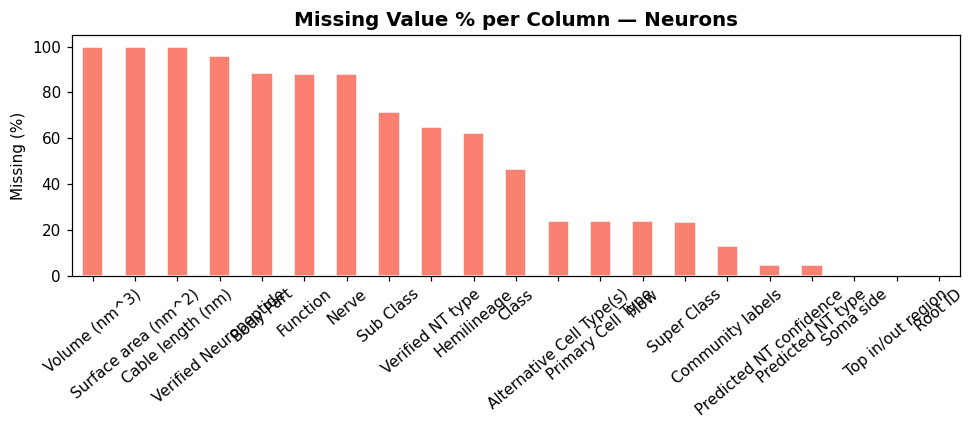

In [2]:
print('Shape:', neurons_df.shape)
print('\nDtypes:')
print(neurons_df.dtypes)
print('\nBasic stats:')
display(neurons_df.describe(include='all'))

miss = missing_data_summary(neurons_df)
print('\nMissing value summary:')
display(miss)

fig, ax = plt.subplots(figsize=(9, 4))
miss['missing_pct'].plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Value % per Column — Neurons', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

## 2. Top In/Out Region Distribution (Top 30)

Total unique regions: 1092
Top in/out region
ME               20826
ME.LO             8895
ME.LOP            4855
LO.LOP            4753
T3_METANM         4244
T1_PRONM          4092
T2_MESONM         4005
LO                3824
GNG               2517
AL                2415
ANM               2274
NO_CONS           2266
LOP               2229
AVLP              2216
ME.NO_CONS        2043
SMP               1693
LO.PVLP           1492
FB                1391
MB_CA             1055
NO_CONS.ME        1014
HTCT               944
WTCT               911
AMNP               882
SLP                765
PLP                741
MB_CA.NO_CONS      694
LH                 670
MB_CA.MB_VL        654
IPS                636
LOP.PLP            610
Name: count, dtype: int64


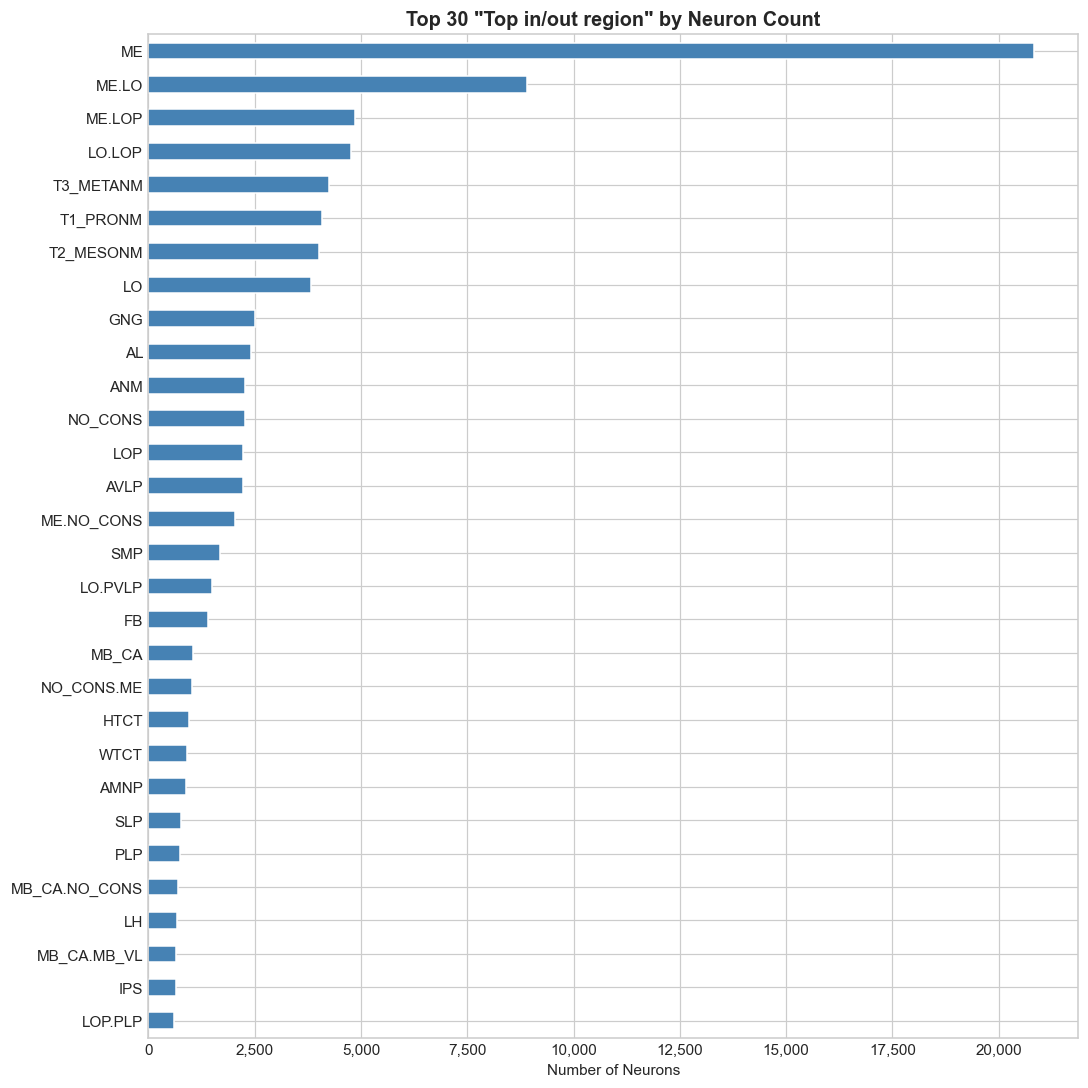

In [3]:
region_counts = neuron_region_counts(neurons_df, top_n=30)
print(f'Total unique regions: {neurons_df["Top in/out region"].nunique()}')
print(region_counts)

plot_barh(
    region_counts,
    title='Top 30 "Top in/out region" by Neuron Count',
    xlabel='Number of Neurons',
    figsize=(10, 10),
    color='steelblue',
)
plt.show()

## 3. Predicted NT Type Distribution

Predicted NT type counts:
Predicted NT type
ACH     65367
GABA    19856
GLUT    15910
DA       5187
SER      2352
HIST      297
OCT       295
TYR       221
Name: count, dtype: int64


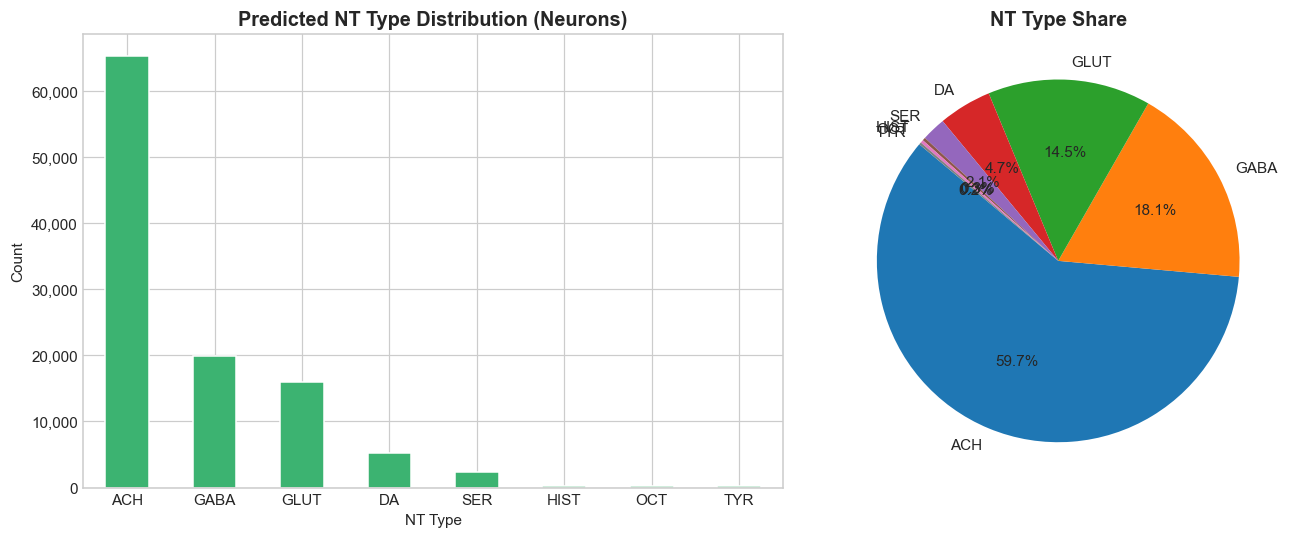

In [4]:
nt_counts = neuron_nt_type_counts(neurons_df)
print('Predicted NT type counts:')
print(nt_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_bar(
    nt_counts,
    title='Predicted NT Type Distribution (Neurons)',
    xlabel='NT Type',
    color='mediumseagreen',
    rotate_xticks=0,
    ax=axes[0],
)

axes[1].pie(nt_counts.values, labels=nt_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('NT Type Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Predicted NT Confidence Distribution

NT Confidence stats:
count    109485.000000
mean          0.770824
std           0.185109
min           0.220000
25%           0.630000
50%           0.820000
75%           0.930000
max           1.000000
Name: Predicted NT confidence, dtype: float64


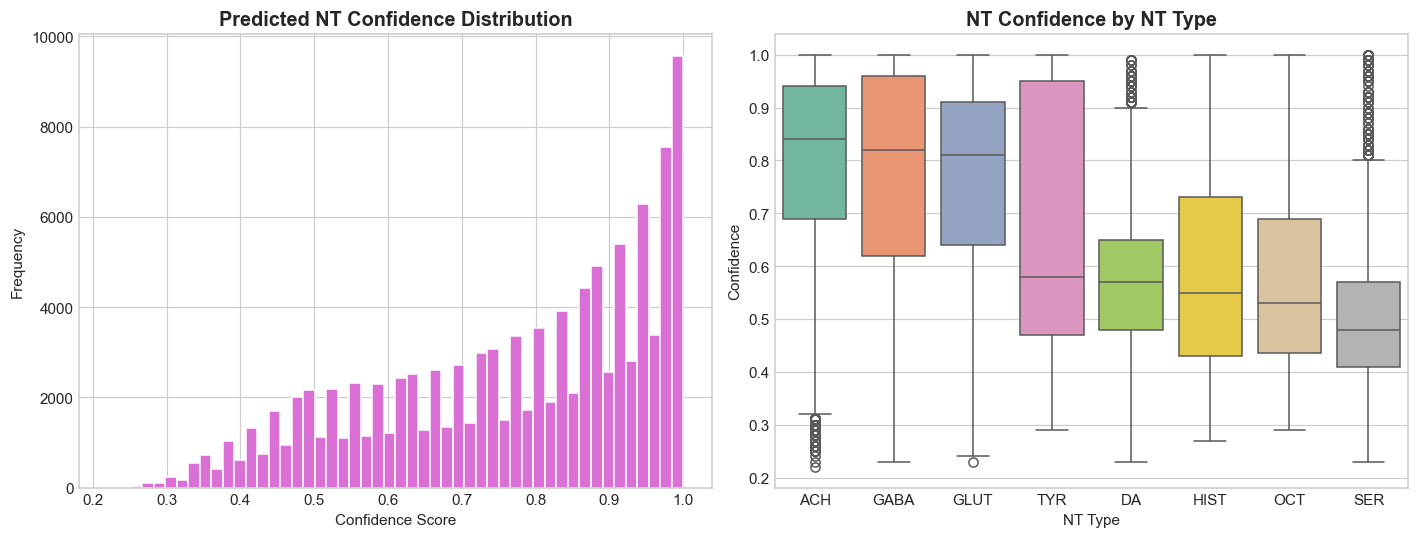

In [5]:
print('NT Confidence stats:')
print(neuron_nt_confidence_stats(neurons_df))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of confidence scores
plot_histogram(
    neurons_df['Predicted NT confidence'],
    title='Predicted NT Confidence Distribution',
    xlabel='Confidence Score',
    bins=50,
    color='orchid',
    ax=axes[0],
)

# Confidence by NT type — box plot
nt_conf = neurons_df.dropna(subset=['Predicted NT type', 'Predicted NT confidence'])
order = nt_conf.groupby('Predicted NT type')['Predicted NT confidence'].median().sort_values(ascending=False).index
sns.boxplot(
    data=nt_conf,
    x='Predicted NT type',
    y='Predicted NT confidence',
    order=order,
    palette='Set2',
    ax=axes[1],
)
axes[1].set_title('NT Confidence by NT Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('NT Type')
axes[1].set_ylabel('Confidence')
plt.tight_layout()
plt.show()

## 5. Body Part Distribution

Body Part counts:
Body Part
antenna                                 2333
hind_leg                                2041
front_leg                               1769
middle_leg                              1643
abdomen                                 1210
interommatidial                         1006
wing_margin                              586
haltere                                  442
labellum                                 435
thorax                                   327
maxillary_palp                           272
postorbital_ventral                      208
wing_base                                131
retina                                   123
wing                                     119
neck                                      98
pharynx                                   89
wing_tegula                               65
retrocerebral_complex                     55
wheelers_organ                            51
abdominal_wall                            45
proboscis                  

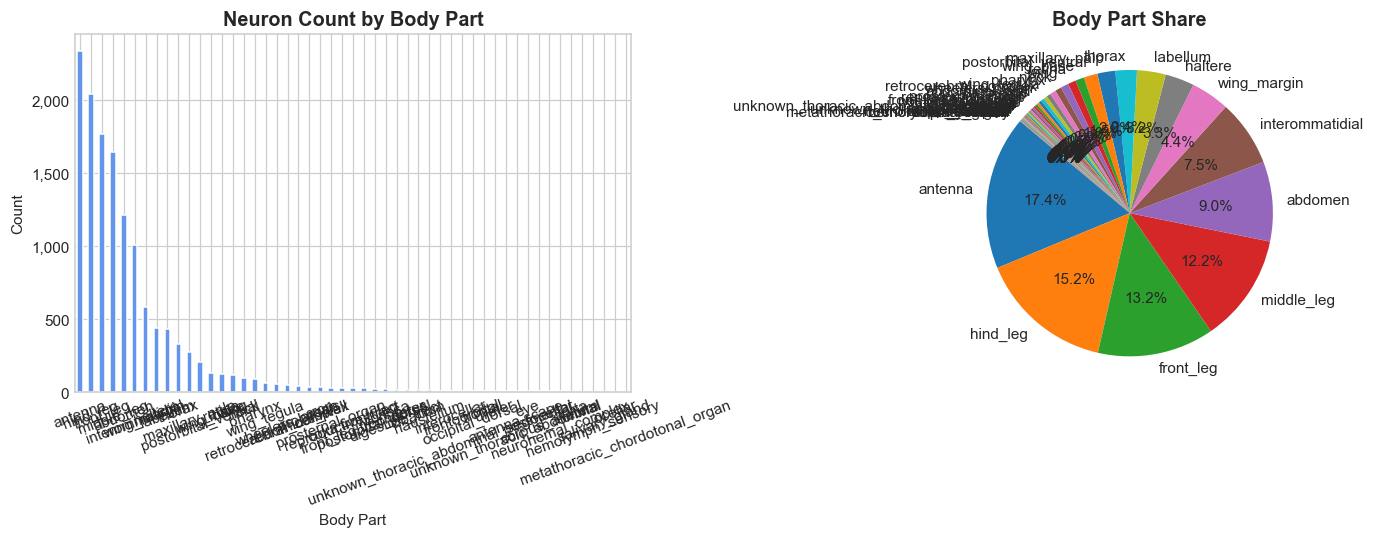

In [6]:
bp_counts = neuron_body_part_counts(neurons_df)
print('Body Part counts:')
print(bp_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_bar(
    bp_counts,
    title='Neuron Count by Body Part',
    xlabel='Body Part',
    color='cornflowerblue',
    rotate_xticks=20,
    ax=axes[0],
)

axes[1].pie(bp_counts.values, labels=bp_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Body Part Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Community Labels (Top 20)

Total unique community labels: 2133
Community labels
soma in brain                                       52124
CNS neuron,soma in brain                            17966
soma in VNC                                         13257
CNS neuron,T5 neuron,soma in brain                   2734
CNS neuron,T4 neuron,soma in brain                   2657
CNS neuron,centrifugal,soma in brain                  929
CNS neuron,T2 neuron,soma in brain                    659
CNS neuron                                            656
CNS neuron,soma in VNC                                344
ascending,sensory neuron                              267
CNS neuron,T4 neuron,T4b?,soma in brain               230
CNS neuron,Tm9?,soma in brain                         211
sensory neuron                                        138
innervates abdomen,innervates right side of body      123
CNS neuron,T4 neuron,T4a?,soma in brain               119
CNS neuron,Mi9?,soma in brain                         118
CB3830,CNS neuron,s

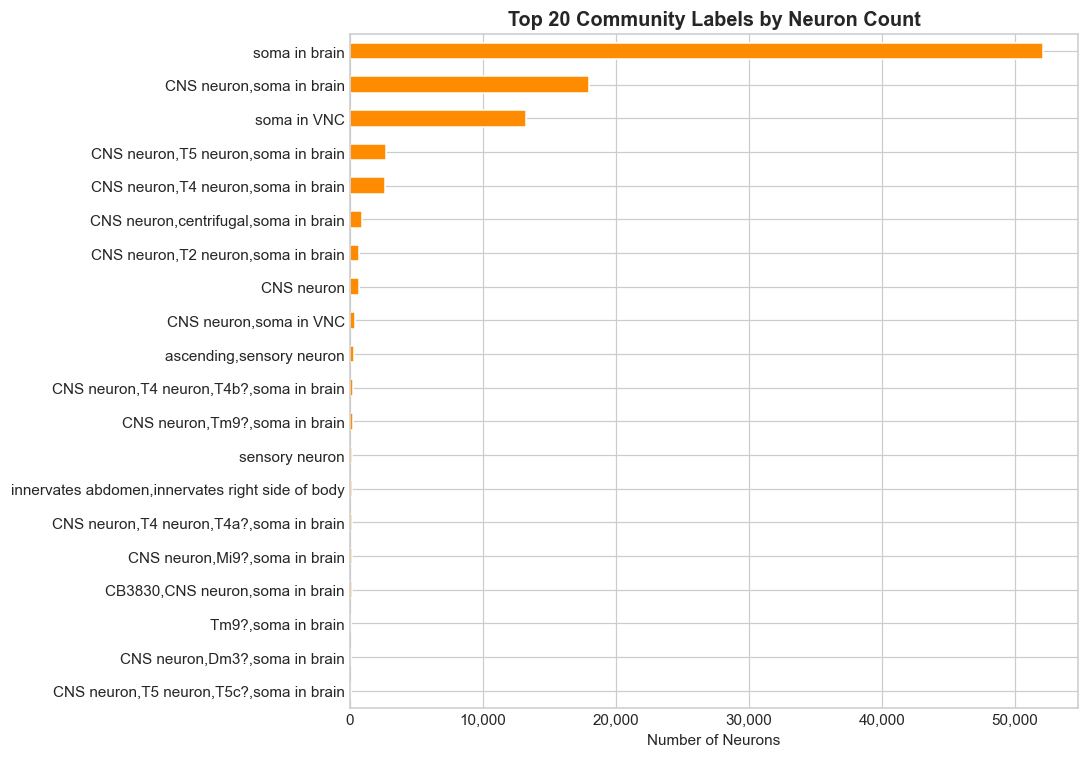

In [3]:
comm_counts = neuron_community_label_counts(neurons_df, top_n=20)
print(f'Total unique community labels: {neurons_df["Community labels"].nunique()}')
print(comm_counts)

plot_barh(
    comm_counts,
    title='Top 20 Community Labels by Neuron Count',
    xlabel='Number of Neurons',
    color='darkorange',
    figsize=(10, 7),
)
plt.show()

## 7. NT Type × Body Part Heatmap

NT type x Body Part counts:


Predicted NT type,ACH,GABA,GLUT,HIST,OCT,SER
Body Part,,,,,,
abdomen,871,48,17,2,55,47
abdominal_wall,11,7,7,0,3,17
antenna,1568,624,0,0,0,8
"antenna,scape",2,1,0,0,0,0
aorta,0,0,0,0,0,1
cibarium,3,0,0,0,0,10
corpus_allatum,1,0,0,0,0,0
"coxa,front_leg",8,18,0,0,0,0
crop,9,13,0,0,0,2


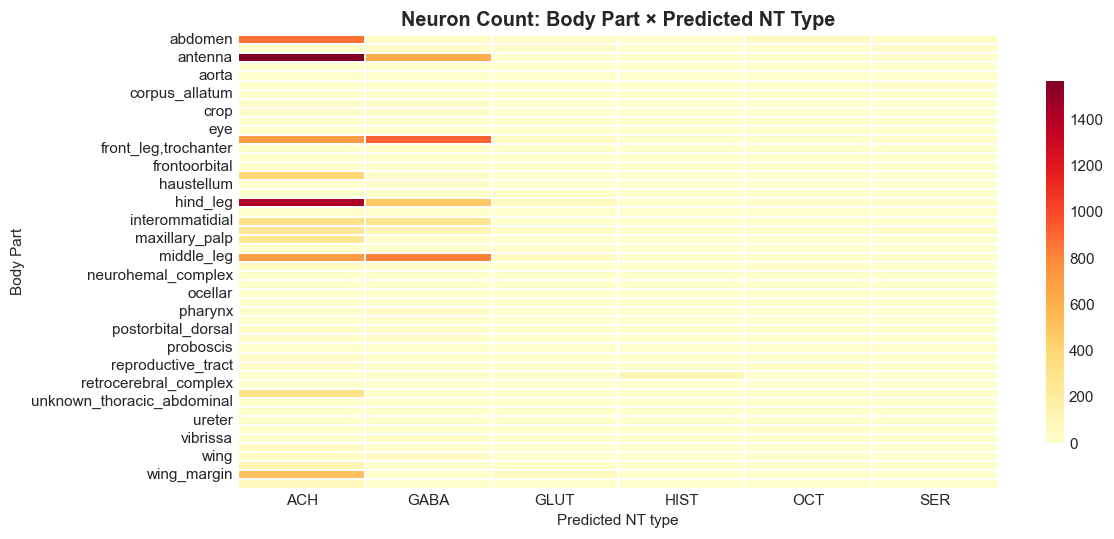

In [8]:
# Cross-tabulation: NT type vs Body Part
cross = (
    neurons_df
    .dropna(subset=['Predicted NT type', 'Body Part'])
    .groupby(['Body Part', 'Predicted NT type'])
    .size()
    .unstack(fill_value=0)
)
print('NT type x Body Part counts:')
display(cross)

plot_heatmap(
    cross,
    title='Neuron Count: Body Part × Predicted NT Type',
    figsize=(11, 5),
    fmt='d',
)
plt.show()

## 8. Top Region × NT Type Heatmap (Top 15 Regions)

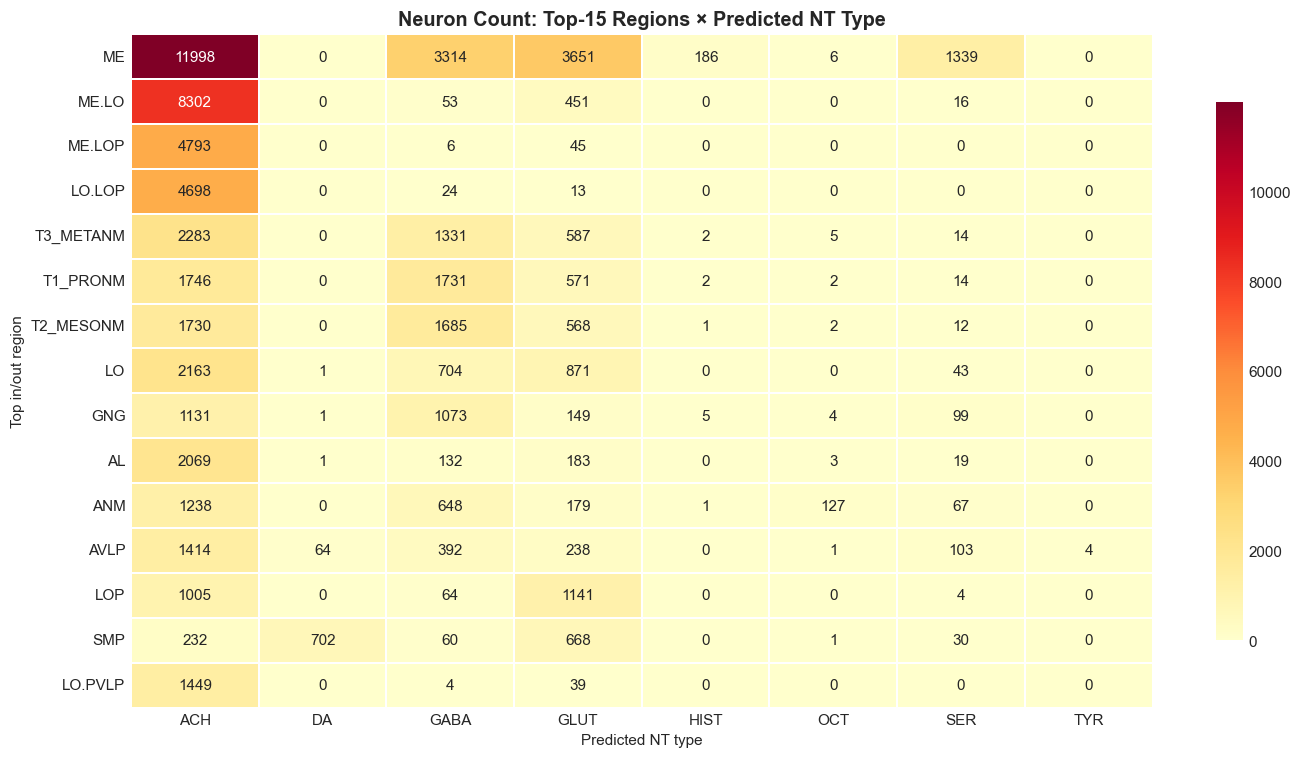

In [4]:
# Cross-tab: Top in/out region vs Predicted NT type
region_nt = (
    neurons_df
    .dropna(subset=['Predicted NT type'])
    .groupby(['Top in/out region', 'Predicted NT type'])
    .size()
    .unstack(fill_value=0)
)
# Keep top 15 regions by total neuron count
top15_regions = region_nt.sum(axis=1).nlargest(15).index
region_nt_top = region_nt.loc[top15_regions]

plot_heatmap(
    region_nt_top,
    title='Neuron Count: Top-15 Regions × Predicted NT Type',
    figsize=(13, 7),
    fmt='d',
)
plt.show()

## 9. Verified vs Predicted NT Type Comparison

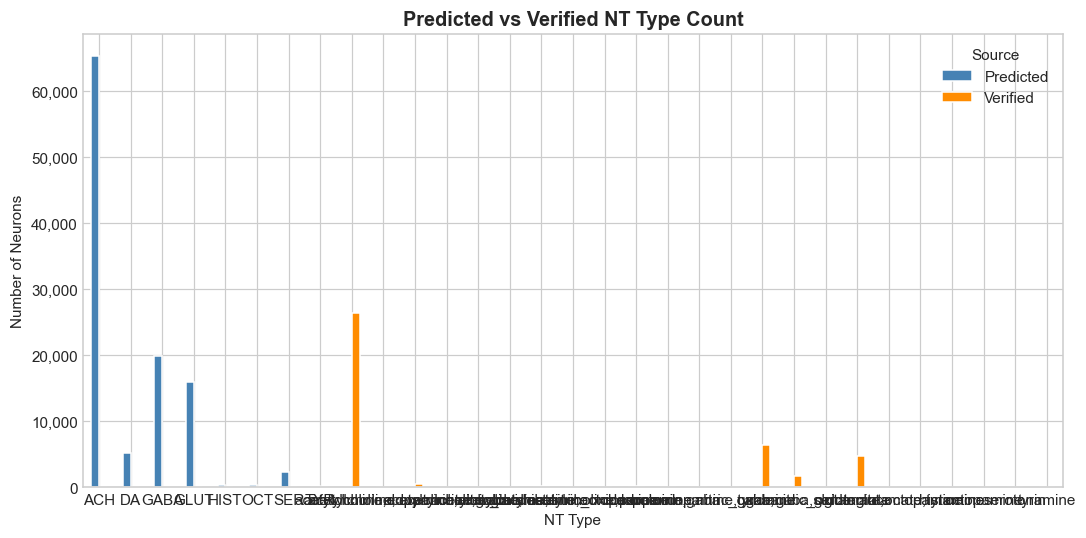

Neurons with verified NT type : 40,568
Neurons with predicted NT type: 109,485


In [10]:
verified = neurons_df['Verified NT type'].value_counts(dropna=True)
predicted = neurons_df['Predicted NT type'].value_counts(dropna=True)

# Align on same index
all_types = sorted(set(verified.index) | set(predicted.index))
comp_df = pd.DataFrame({
    'Predicted': predicted.reindex(all_types, fill_value=0),
    'Verified':  verified.reindex(all_types, fill_value=0),
})

fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind='bar', ax=ax, edgecolor='white', color=['steelblue', 'darkorange'])
ax.set_title('Predicted vs Verified NT Type Count', fontsize=13, fontweight='bold')
ax.set_xlabel('NT Type')
ax.set_ylabel('Number of Neurons')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Source')
plt.tight_layout()
plt.show()

print(f'Neurons with verified NT type : {verified.sum():,}')
print(f'Neurons with predicted NT type: {predicted.sum():,}')

## 10. Summary Statistics Table

In [11]:
summary = {
    'Total neurons': len(neurons_df),
    'Unique regions (Top in/out)': neurons_df['Top in/out region'].nunique(),
    'Unique community labels': neurons_df['Community labels'].nunique(),
    'Unique predicted NT types': neurons_df['Predicted NT type'].nunique(),
    'Unique verified NT types': neurons_df['Verified NT type'].nunique(),
    'Neurons w/ predicted NT': neurons_df['Predicted NT type'].notna().sum(),
    'Neurons w/ verified NT': neurons_df['Verified NT type'].notna().sum(),
    'Neurons w/ body part label': neurons_df['Body Part'].notna().sum(),
    'Mean NT confidence': round(neurons_df['Predicted NT confidence'].mean(), 3),
    'Median NT confidence': round(neurons_df['Predicted NT confidence'].median(), 3),
}

for k, v in summary.items():
    if isinstance(v, int):
        print(f'{k:<40} {v:>12,}')
    else:
        print(f'{k:<40} {v:>12}')

Total neurons                                 115,151
Unique regions (Top in/out)                     1,092
Unique community labels                         2,133
Unique predicted NT types                           8
Unique verified NT types                           23
Neurons w/ predicted NT                        109485
Neurons w/ verified NT                          40568
Neurons w/ body part label                      13441
Mean NT confidence                              0.771
Median NT confidence                             0.82


# BANC Dataset — Neuron Visualization

Exploratory visualization of `neurons.csv.gz` (115,151 neurons).

**Columns:** `Root ID`, `Top in/out region`, `Community labels`, `Predicted NT type`, `Predicted NT confidence`, `Verified NT type`, `Verified Neuropeptide`, `Body Part`

In [12]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from banc_utils import (
    load_neurons,
    missing_data_summary,
    neuron_region_counts,
    neuron_nt_type_counts,
    neuron_body_part_counts,
    neuron_community_label_counts,
    neuron_nt_confidence_stats,
    plot_bar, plot_barh, plot_pie, plot_histogram,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Imports OK')

Imports OK


## 1. Load Data

In [13]:
neurons_df = load_neurons('neurons.csv.gz')
print(f'Shape: {neurons_df.shape}')
print(f'Columns: {list(neurons_df.columns)}')
neurons_df.head()

Shape: (115151, 21)
Columns: ['Root ID', 'Top in/out region', 'Community labels', 'Predicted NT type', 'Predicted NT confidence', 'Verified NT type', 'Verified Neuropeptide', 'Body Part', 'Function', 'Flow', 'Super Class', 'Class', 'Sub Class', 'Hemilineage', 'Nerve', 'Soma side', 'Primary Cell Type', 'Alternative Cell Type(s)', 'Cable length (nm)', 'Surface area (nm^2)', 'Volume (nm^3)']


,Root ID,Top in/out region,Community labels,Predicted NT type,Predicted NT confidence,Verified NT type,Verified Neuropeptide,Body Part,Function,Flow,...,Class,Sub Class,Hemilineage,Nerve,Soma side,Primary Cell Type,Alternative Cell Type(s),Cable length (nm),Surface area (nm^2),Volume (nm^3)
0,720575940381905254,NO_CONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,720575940386709331,NO_CONS,soma in brain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,720575940387110289,NO_CONS,sensory neuron,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,720575940389711170,NO_CONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,720575940407089948,NO_CONS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Data Overview

                          missing_count  missing_pct
Volume (nm^3)                    115151       100.00
Surface area (nm^2)              115151       100.00
Cable length (nm)                115151       100.00
Verified Neuropeptide            110318        95.80
Body Part                        101710        88.33
Function                         101299        87.97
Nerve                            101291        87.96
Sub Class                         82116        71.31
Verified NT type                  74583        64.77
Hemilineage                       71910        62.45
Class                             53742        46.67
Alternative Cell Type(s)          27509        23.89
Primary Cell Type                 27509        23.89
Flow                              27314        23.72
Super Class                       26792        23.27
Community labels                  14896        12.94
Predicted NT confidence            5666         4.92
Predicted NT type                  5666       

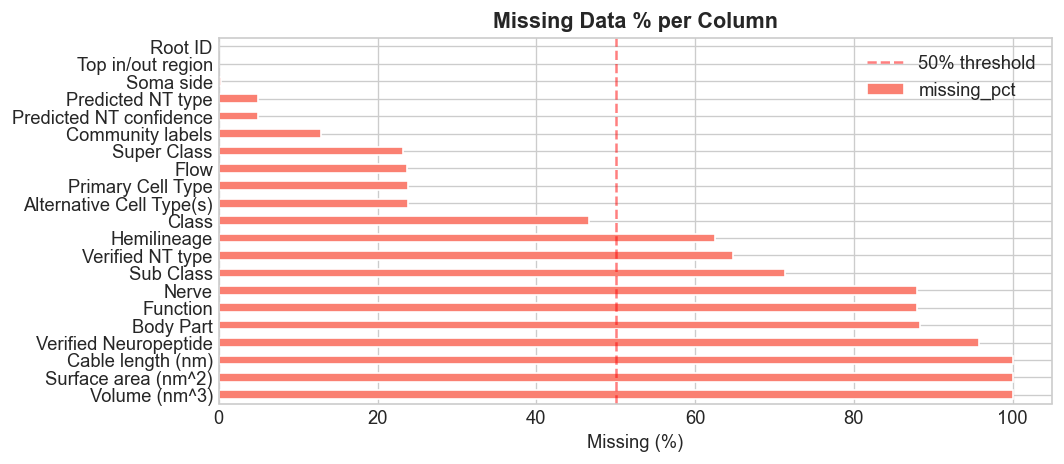

In [14]:
miss = missing_data_summary(neurons_df)
print(miss)

fig, ax = plt.subplots(figsize=(9, 4))
miss['missing_pct'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Data % per Column', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Top In/Out Region Distribution

Total unique regions: 1092


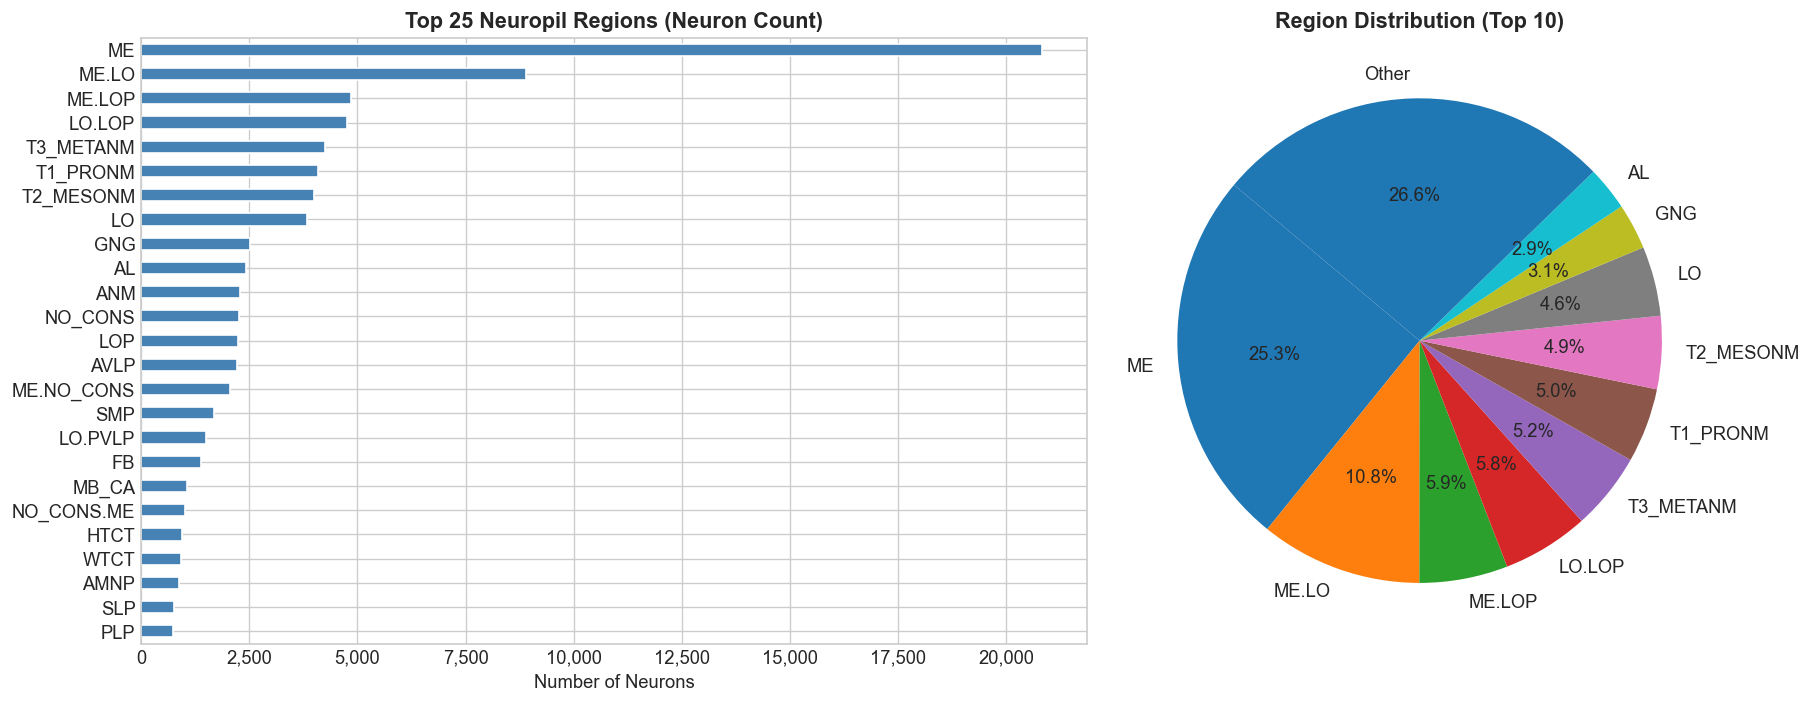

In [15]:
region_counts = neuron_region_counts(neurons_df, top_n=25)
print(f"Total unique regions: {neurons_df['Top in/out region'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_barh(region_counts, title='Top 25 Neuropil Regions (Neuron Count)',
          xlabel='Number of Neurons', color='steelblue', ax=axes[0])
plot_pie(region_counts, title='Region Distribution (Top 10)', max_slices=10, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Body Part Distribution

Body Part value counts:
Body Part
antenna                                 2333
hind_leg                                2041
front_leg                               1769
middle_leg                              1643
abdomen                                 1210
interommatidial                         1006
wing_margin                              586
haltere                                  442
labellum                                 435
thorax                                   327
maxillary_palp                           272
postorbital_ventral                      208
wing_base                                131
retina                                   123
wing                                     119
neck                                      98
pharynx                                   89
wing_tegula                               65
retrocerebral_complex                     55
wheelers_organ                            51
abdominal_wall                            45
proboscis            

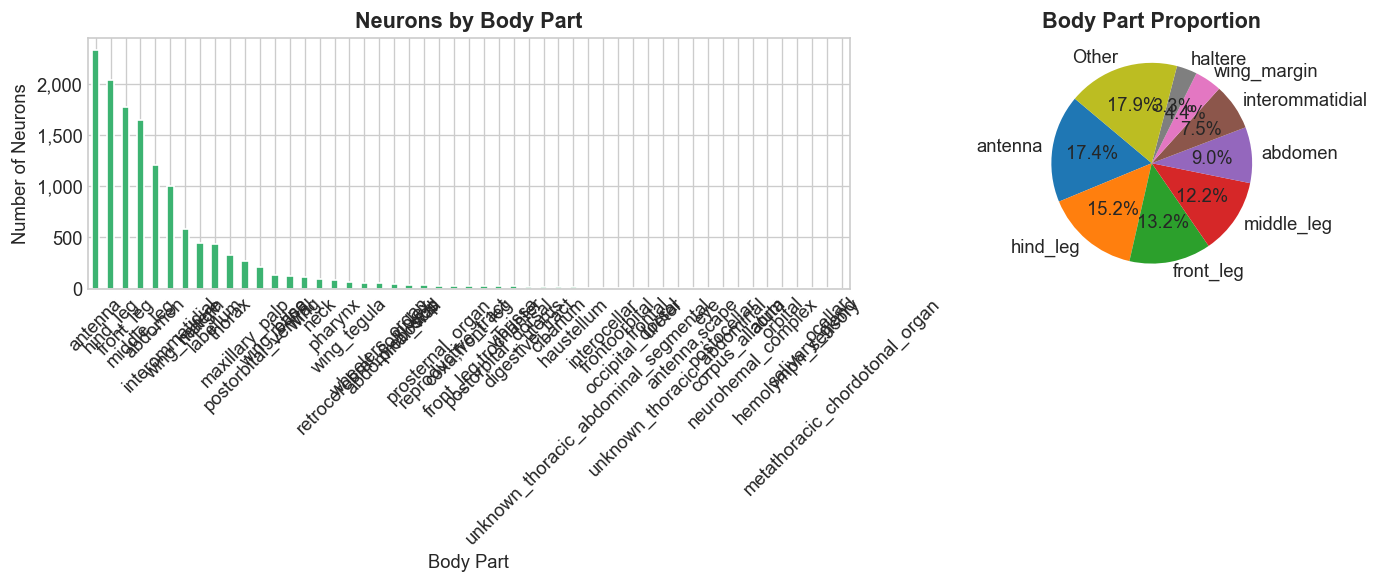

In [16]:
body_counts = neuron_body_part_counts(neurons_df)
print('Body Part value counts:')
print(body_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar(body_counts, title='Neurons by Body Part', xlabel='Body Part',
         ylabel='Number of Neurons', color='mediumseagreen', ax=axes[0])
plot_pie(body_counts, title='Body Part Proportion', max_slices=8, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Predicted Neurotransmitter (NT) Type

Prediction coverage: 95.1% of neurons
Predicted NT type
ACH     65367
GABA    19856
GLUT    15910
DA       5187
SER      2352
HIST      297
OCT       295
TYR       221
Name: count, dtype: int64


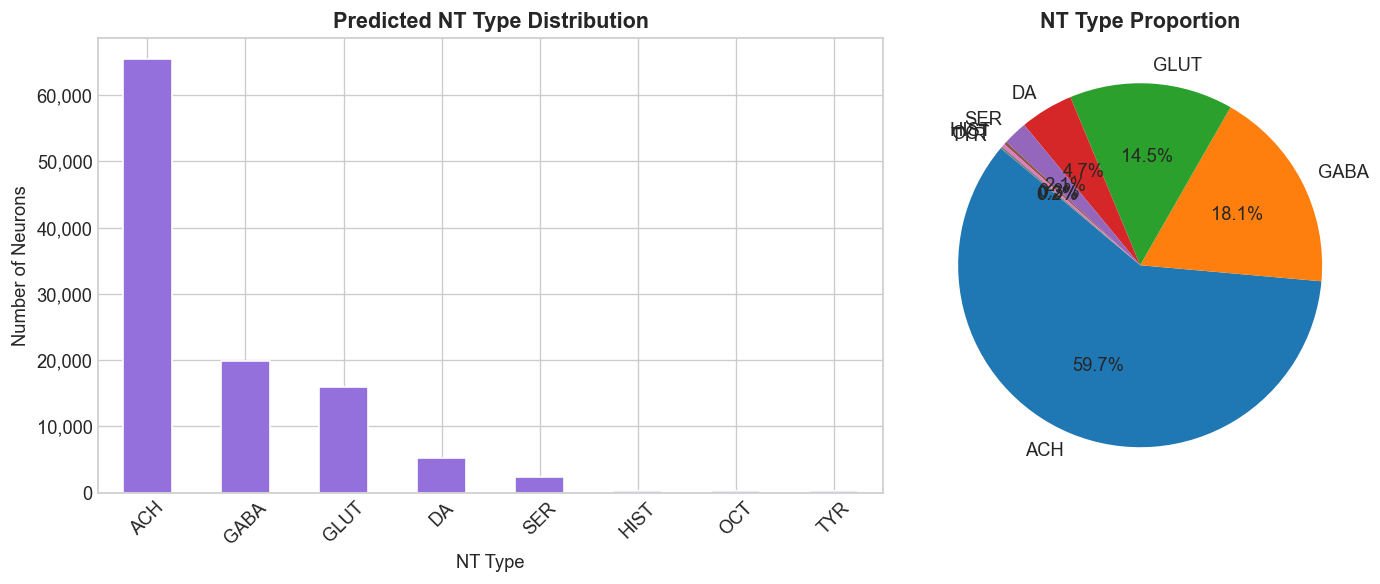

In [17]:
nt_counts = neuron_nt_type_counts(neurons_df)
coverage = neurons_df['Predicted NT type'].notna().mean() * 100
print(f'Prediction coverage: {coverage:.1f}% of neurons')
print(nt_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_bar(nt_counts, title='Predicted NT Type Distribution',
         xlabel='NT Type', ylabel='Number of Neurons',
         color='mediumpurple', ax=axes[0])
plot_pie(nt_counts, title='NT Type Proportion', max_slices=10, ax=axes[1])
plt.tight_layout()
plt.show()

## 6. NT Prediction Confidence

Confidence statistics:
count    109485.000000
mean          0.770824
std           0.185109
min           0.220000
25%           0.630000
50%           0.820000
75%           0.930000
max           1.000000
Name: Predicted NT confidence, dtype: float64


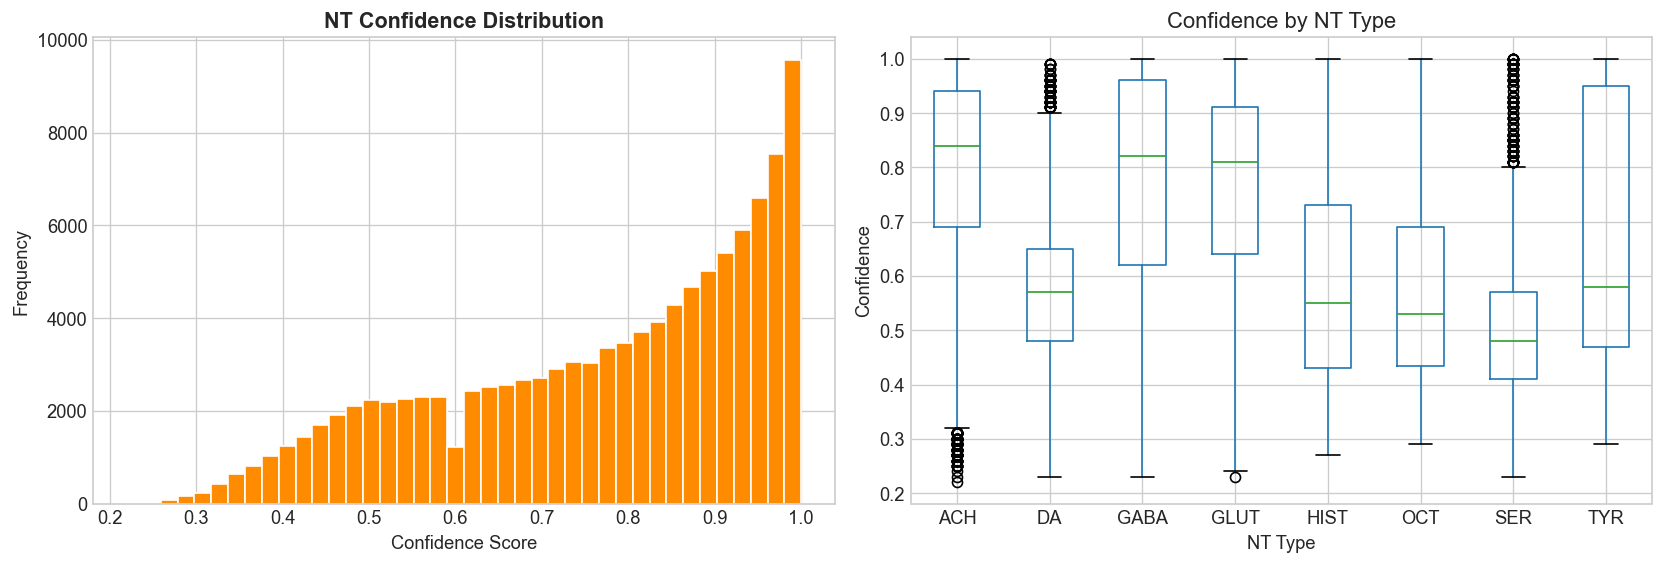

In [18]:
print('Confidence statistics:')
print(neuron_nt_confidence_stats(neurons_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_histogram(neurons_df['Predicted NT confidence'],
               title='NT Confidence Distribution',
               xlabel='Confidence Score', bins=40,
               color='darkorange', ax=axes[0])

sub = neurons_df.dropna(subset=['Predicted NT type', 'Predicted NT confidence'])
sub.boxplot(column='Predicted NT confidence', by='Predicted NT type',
            ax=axes[1], grid=True)
axes[1].set_title('Confidence by NT Type')
axes[1].set_xlabel('NT Type')
axes[1].set_ylabel('Confidence')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 7. Community Labels

Community label coverage: 87.1%
Total unique labels: 2133


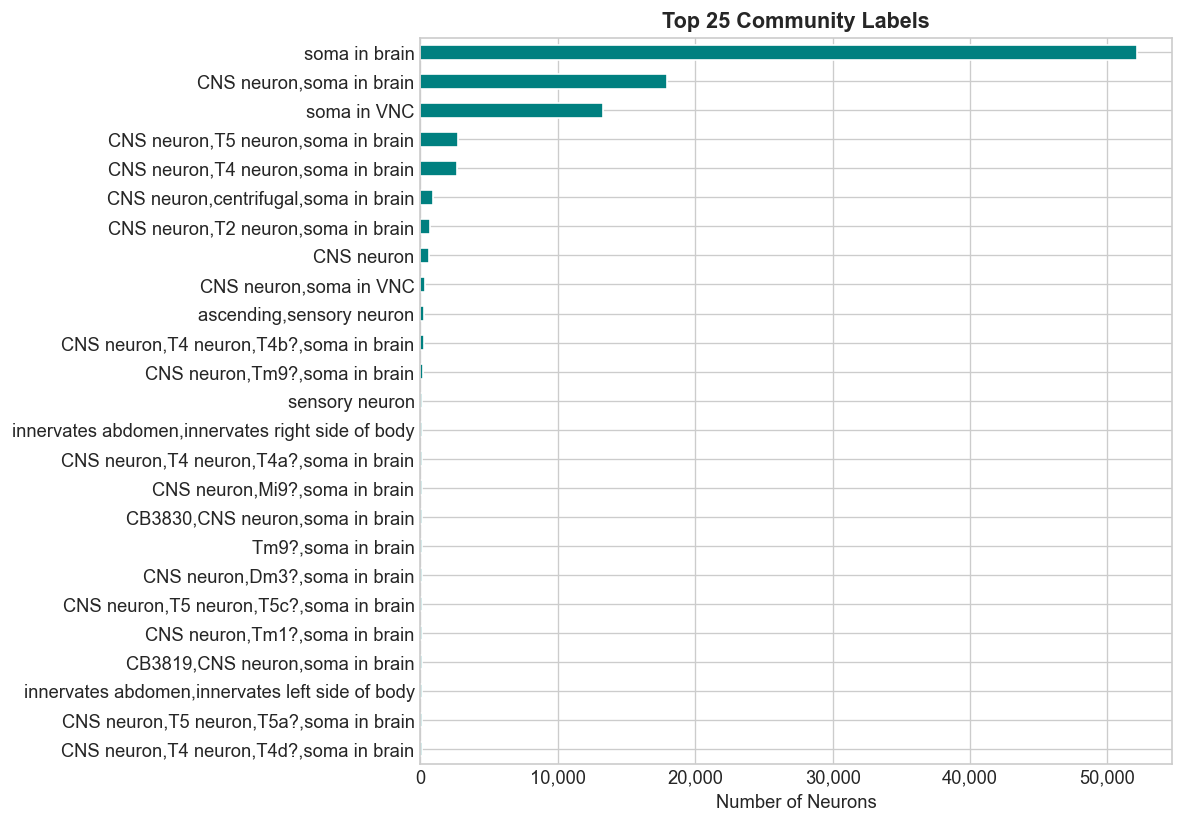

In [19]:
community_counts = neuron_community_label_counts(neurons_df, top_n=25)
coverage_c = neurons_df['Community labels'].notna().mean() * 100
print(f'Community label coverage: {coverage_c:.1f}%')
print(f"Total unique labels: {neurons_df['Community labels'].nunique()}")

plot_barh(community_counts,
          title='Top 25 Community Labels',
          xlabel='Number of Neurons',
          color='teal', figsize=(10, 7))
plt.show()

## 8. Verified vs Predicted NT Type

Neurons with both predicted and verified NT: 39642
Agreement rate: 0.0%


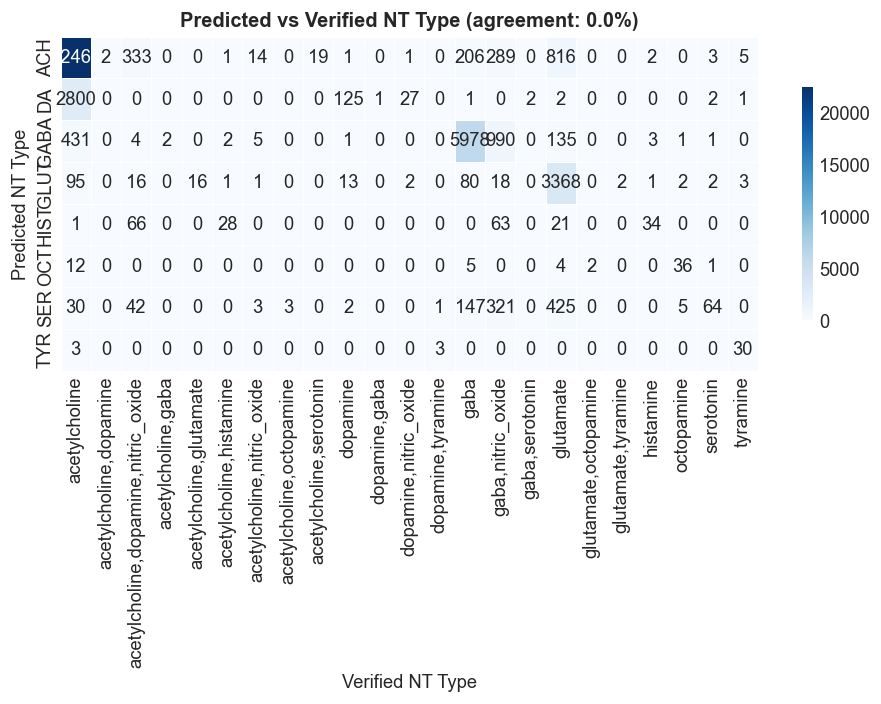

In [20]:
both = neurons_df.dropna(subset=['Predicted NT type', 'Verified NT type']).copy()
print(f'Neurons with both predicted and verified NT: {len(both)}')

if len(both) > 0:
    both['match'] = both['Predicted NT type'] == both['Verified NT type']
    agreement = both['match'].mean() * 100
    print(f'Agreement rate: {agreement:.1f}%')
    confusion = pd.crosstab(both['Predicted NT type'], both['Verified NT type'])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.5, cbar_kws={'shrink': 0.7})
    ax.set_title(f'Predicted vs Verified NT Type (agreement: {agreement:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Verified NT Type')
    ax.set_ylabel('Predicted NT Type')
    plt.tight_layout()
    plt.show()
else:
    verified = neurons_df['Verified NT type'].value_counts(dropna=True)
    if len(verified) > 0:
        plot_bar(verified, title='Verified NT Type Distribution', xlabel='NT Type', color='teal')
        plt.show()
    else:
        print('No verified NT type data available.')

## 9. NT Type Distribution per Body Part (Stacked Bar)

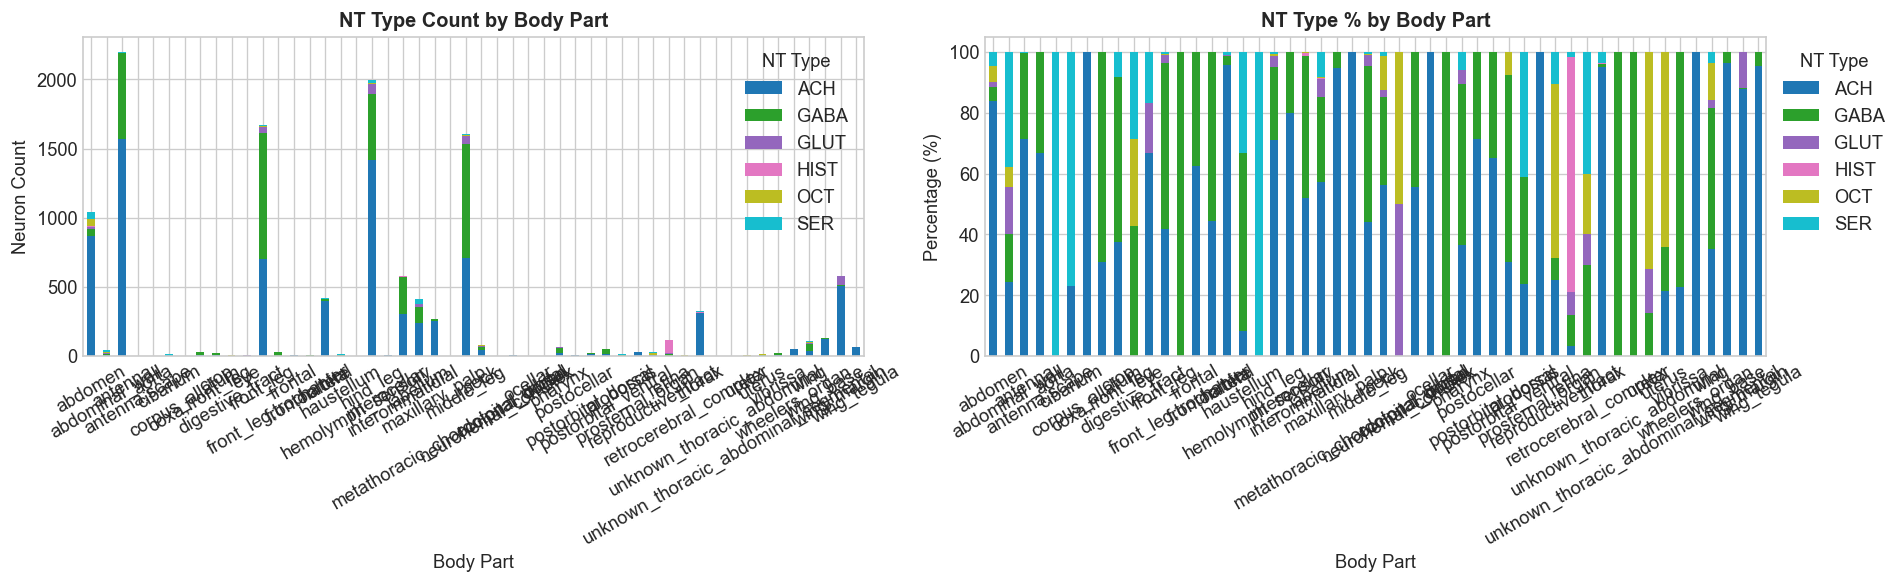

In [21]:
sub = neurons_df.dropna(subset=['Predicted NT type', 'Body Part'])
pivot = pd.crosstab(sub['Body Part'], sub['Predicted NT type'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', edgecolor='none')
axes[0].set_title('NT Type Count by Body Part', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Body Part')
axes[0].set_ylabel('Neuron Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='NT Type', bbox_to_anchor=(1.0, 1.0))

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='none')
axes[1].set_title('NT Type % by Body Part', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Body Part')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='NT Type', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [22]:
summary = pd.DataFrame({
    'Total neurons': [len(neurons_df)],
    'Unique regions': [neurons_df['Top in/out region'].nunique()],
    'Unique body parts': [neurons_df['Body Part'].nunique()],
    'NT type coverage (%)': [round(neurons_df['Predicted NT type'].notna().mean()*100, 1)],
    'Verified NT coverage (%)': [round(neurons_df['Verified NT type'].notna().mean()*100, 1)],
    'Community label coverage (%)': [round(neurons_df['Community labels'].notna().mean()*100, 1)],
    'Mean NT confidence': [round(neurons_df['Predicted NT confidence'].mean(), 3)],
}).T
summary.columns = ['Value']
summary

,Value
Total neurons,115151.000
Unique regions,1092.000
Unique body parts,51.000
NT type coverage (%),95.100
Verified NT coverage (%),35.200
Community label coverage (%),87.100
Mean NT confidence,0.771
